# Brute Force Approach for Minimum fuel Trajectories in Earth Moon System

This notebook applies a brute force approach to solve the problem of launching a rocket from Low Earth Orbit (LEO) to Low Moon Orbit (LMO).

Two impulsive burns are appied. One at LEO and one at LMO.

The time of flight and phase of departure are also optimized

### Imports

In [1]:
import numpy as np
from cr3bp import (
    create_earth_moon_system,
    plot_trajectory,
    decision_to_state0,
    evaluate,
    grid_search_method
)

### Initialize the System / Problem

In [2]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()
print(em.info())

CR3BP System Information:
  Primary 1 mass: 5.972e+24 kg
  Primary 2 mass: 7.342e+22 kg
  Primary 1 radius: 6.371e+06 m
  Primary 2 radius: 1.737e+06 m
  Total mass: 6.045e+24 kg
  Distance: 3.844e+08 m (384400.0 km)
  Mass parameter μ: 0.012145

Characteristic scales:
  Length (l*): 3.844e+08 m (384400.0 km)
  Time (t*): 3.752e+05 s (4.343 days)
  Velocity (v*): 1.025e+03 m/s (1.025 km/s)
  Acceleration (a*): 2.731e-03 m/s^2
  Period: 27.285 days
None


In [3]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

## Results

In [ ]:
optimals = np.load("grid_search_results.npy")

In [ ]:
optimal_theta = optimals[0]
optimal_delta_v = optimals[1]
optimal_delta_v_angle = optimals[2]
optimal_tof = optimals[3]
print(f"Optimal Delta_v from Grid Search: {optimal_delta_v*em.v_star*1e-3:.2f} km/s")
print(f"Optimal Theta from Grid Search: {optimal_theta:.2f} rad")
print(f"Optimal Delta_v Angle from Grid Search: {optimal_delta_v_angle:.2f} rad")
print(f"Optimal Time of Flight from Grid Search: {optimal_tof:.2f} s")

Optimal Delta_v from Grid Search: 3.10 km/s
Optimal Theta from Grid Search: 4.01 rad
Optimal Delta_v Angle from Grid Search: 0.10 rad
Optimal Time of Flight from Grid Search: 0.81 s


### Run the trajectory to plot

In [ ]:
x0 = np.array(optimals)
state0 = decision_to_state0(em, x0, leo_alt_m)

In [ ]:
tof = x0[3]
t_span = (0,tof)
t_eval = np.linspace(0, tof, 1000)
states, ts, sol = em.solve(state0, t_span, t_eval)

In [ ]:
constraint_value, objective_value = evaluate(em, x0, leo_alt_m=leo_alt_m, lmo_alt_m=lmo_alt_m)

## Plot Trajectory

Distance from moon : 744 km
Distance from LMO of 100km : 644 km
Total Delta_v required : 4.25 km/s


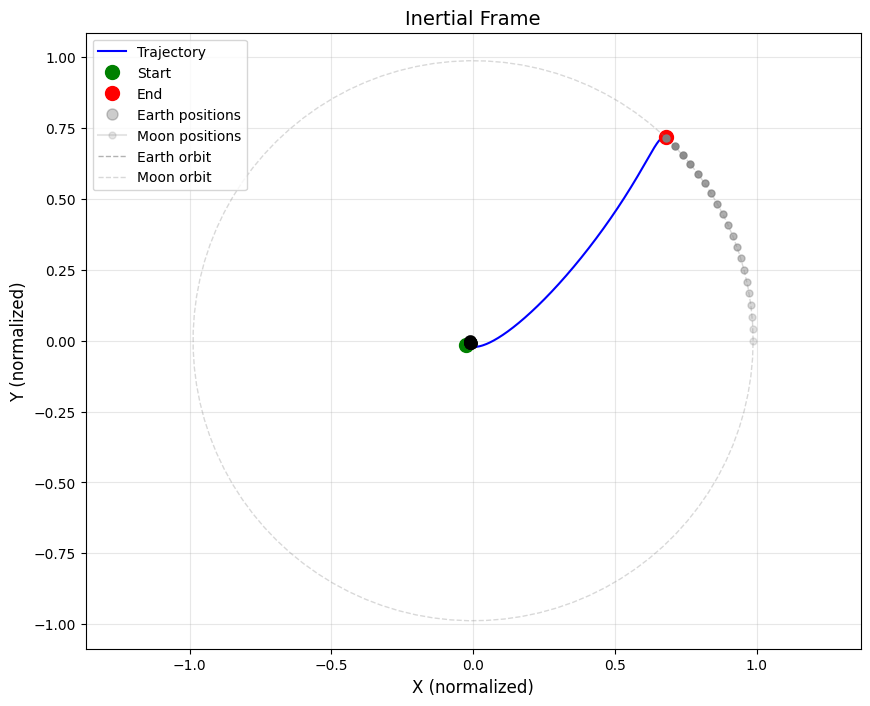

In [ ]:
pos_f = states[:,-1][0:3]
#print(f"Rocket Final Pos in Rotating Frame (normalized units): {pos_f}")
print(f"Distance from moon : {1e-3*(constraint_value*em.l_star + lmo_alt_m):.0f} km")
print(f"Distance from LMO of 100km : {constraint_value*em.l_star * 1e-3:.0f} km")
print(f"Total Delta_v required : {objective_value*em.v_star * 1e-3:.2f} km/s")
plot_trajectory(states, em.mu, t_eval, frame="Inertial")